In [20]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error
import HierarchBayesParcel.arrangements as ar
import nitools as nt
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations

In [21]:
atlas,_= am.get_atlas(atlas_str='SUIT3')

In [22]:
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

In [23]:
ar_model_logpi = full_model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

In [24]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

In [25]:
# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

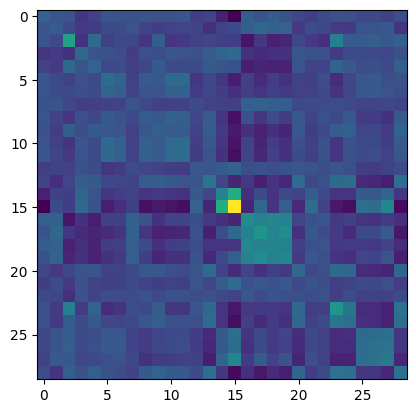

In [8]:
plt.imshow(GL_mdtb)

In [26]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondRun')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0



In [27]:
def HBP_u(train_data,cond_vec,part_vec):
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    kappa = M_1.emissions[0].kappa

    return U_data,kappa

In [28]:
def projection_U(Vs,Y):
    U = Vs.T @ Y
    return U


In [59]:
def evaluate_cos(D, ytrain,info, Vs,ytest_run, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}

    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    U_list = []
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)

        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


        y_subset = ytrain[:, task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)
        y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


        # leverage repeats for HBP
        HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=2)
        U_hat_HBP ,kappa = HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)
        U_list.append(U_hat_HBP)
        U_hat_HBP = [U_hat_HBP]
        kappa = kappa.item()     
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M_test, tdata=ytest_run, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    
    return D, U_list

In [34]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 16)
part_vec_test = np.repeat(np.arange(1, 16 + 1), 32)
data_test = data_mdtb_s2_run


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


Likelihood decreased - terminating on iteration 21


In [ ]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',offs = offsets,n_iter=40000,n_tasks=8,seed=3)
D_mdtb , U_list= evaluate_cos(D_mdtb, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb,data_mdtb_s2_run, VL_mdtb_2,M_2)


building0


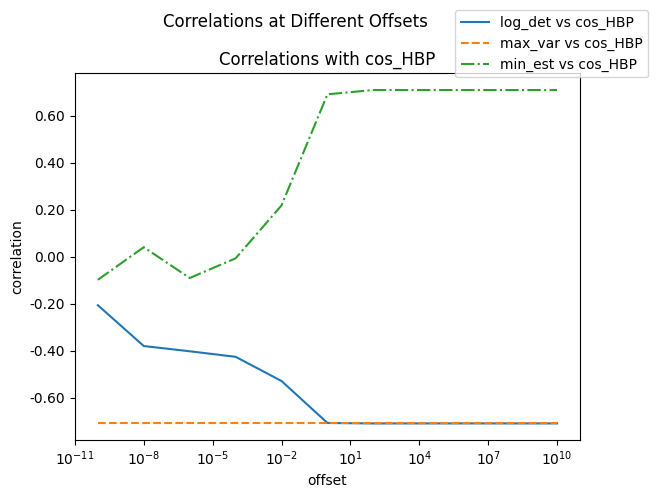

In [19]:
plot_correlations(D_mdtb, x_vars=['log_det','max_var','min_est'], y_vars=['cos_HBP'])

In [66]:
# find the combination with the lowest cos_HBP , use one offset for the dataframe
D_offset = D_mdtb[D_mdtb['offset'] == 1e-2].reset_index(drop=True)
best_comb_index = D_offset['cos_HBP'].idxmin()
worst_comb_index = D_offset['cos_HBP'].idxmax()

print(best_comb_index)
print(worst_comb_index)

best_comb_us = U_list[best_comb_index]
worst_comb_us = U_list[worst_comb_index]

99
75


In [64]:
D_offset

,offset,max_var,max_var_2,min_est,log_det,eigenvalues,n_tasks,combination,has_repeats,n_unique,combination_tuple,cos_HBP
4,0.01,0.653346,0.763210,336.597511,-21.930094,"[0.2892866172170425, 0.16154088953195977, 0.11...",8,"[10, 24, 25, 3, 24, 8, 0, 21]",1,7,"(10, 24, 25, 3, 24, 8, 0, 21)",0.751170
4,0.01,0.975935,1.044330,338.956605,-21.022409,"[0.4157590418335779, 0.36495601433770675, 0.12...",8,"[19, 10, 11, 25, 9, 10, 21, 23]",1,7,"(19, 10, 11, 25, 9, 10, 21, 23)",0.743409
4,0.01,0.771569,0.790615,351.655415,-22.111999,"[0.34734420566439567, 0.2772479053800722, 0.08...",8,"[6, 0, 20, 12, 7, 14, 24, 26]",0,8,"(6, 0, 20, 12, 7, 14, 24, 26)",0.753701
4,0.01,1.237923,1.441299,373.011858,-21.411709,"[0.7715565766046765, 0.27540358853865615, 0.14...",8,"[17, 26, 22, 2, 2, 28, 1, 19]",1,7,"(17, 26, 22, 2, 2, 28, 1, 19)",0.740704
4,0.01,0.861856,0.970893,335.195554,-21.305056,"[0.45509746399628176, 0.21456667857775483, 0.1...",8,"[26, 5, 8, 14, 1, 10, 24, 27]",0,8,"(26, 5, 8, 14, 1, 10, 24, 27)",0.752124
...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.01,0.474161,0.775538,428.525653,-25.069380,"[0.30644981496284096, 0.07341177355021038, 0.0...",8,"[21, 21, 3, 9, 24, 28, 24, 13]",1,6,"(21, 21, 3, 9, 24, 28, 24, 13)",0.745855
4,0.01,1.729458,1.839824,329.575092,-19.164808,"[0.9499506515057554, 0.46689150120354217, 0.23...",8,"[0, 26, 18, 23, 23, 27, 6, 15]",1,7,"(0, 26, 18, 23, 23, 27, 6, 15)",0.732876
4,0.01,0.880859,1.073760,329.779146,-20.898862,"[0.41269291076846626, 0.24513319319387472, 0.1...",8,"[1, 26, 27, 11, 3, 4, 2, 10]",0,8,"(1, 26, 27, 11, 3, 4, 2, 10)",0.750096
4,0.01,0.993127,1.085536,347.835367,-21.055758,"[0.41239105037502655, 0.322776849665236, 0.201...",8,"[0, 1, 13, 5, 14, 27, 17, 1]",1,7,"(0, 1, 13, 5, 14, 27, 17, 1)",0.752052


In [41]:
def evaluate_cos_single(combination, ytrain,info, Vs,ytest_run, vtest,M_test):
    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    # Get the task subset indices and corresponding data
    task_subset_indices = list(combination)

    V_subset = Vs[task_subset_indices, :]
    V_subset = V_subset - np.mean(V_subset, axis=0)
    V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


    y_subset = ytrain[:, task_subset_indices, :]
    y_subset = y_subset - np.mean(y_subset, axis=0)
    y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


    # leverage repeats for HBP
    HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=2)
    U_hat_HBP ,kappa = HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)
    U_hat_HBP = [U_hat_HBP]

    # Compute cos_HBP
    cos_HBP = calc_test_error(M=M_test, tdata=ytest_run, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()


    
    return cos_HBP,U_hat_HBP[0]

In [42]:
combination = (3,4,3,4,3,4,3,4)
cos_HBP,U_hat_HBP = evaluate_cos_single(combination, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb,data_mdtb_s2_run, VL_mdtb_2,M_2)


Likelihood decreased - terminating on iteration 14
Subject:0:0.0872s
Subject:1:0.0360s
Subject:2:0.0369s
Subject:3:0.0378s
Subject:4:0.0408s
Subject:5:0.0394s
Subject:6:0.0355s
Subject:7:0.0378s
Subject:8:0.0357s
Subject:9:0.0410s
Subject:10:0.0405s
Subject:11:0.0393s
Subject:12:0.0434s
Subject:13:0.0355s
Subject:14:0.0334s
Subject:15:0.0348s
Subject:16:0.0350s
Subject:17:0.0363s
Subject:18:0.0367s
Subject:19:0.0338s
Subject:20:0.0360s
Subject:21:0.0357s
Subject:22:0.0350s
Subject:23:0.0366s


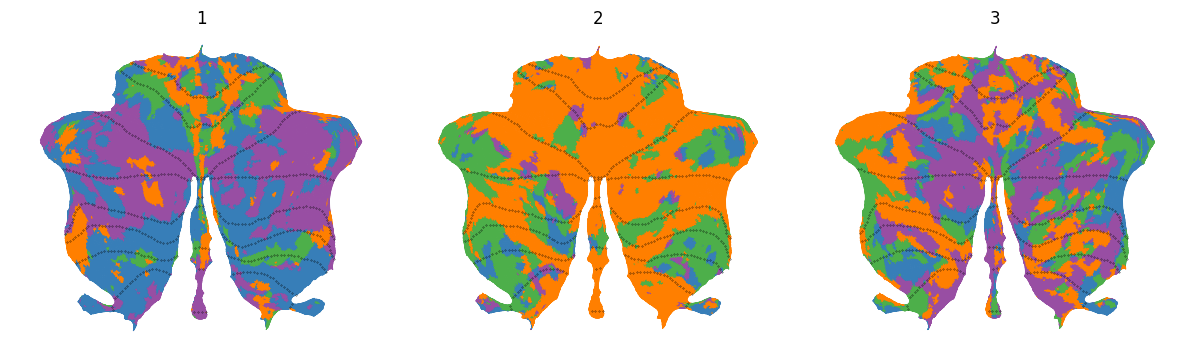

In [67]:
from Functional_Fusion.util import get_volumes
import SUITPy.flatmap as flatmap

U_individual_volumes = get_volumes(U_hat_HBP[:3].cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,4),
                        bordersize = 0.5,
                        fig_size = (20,20))

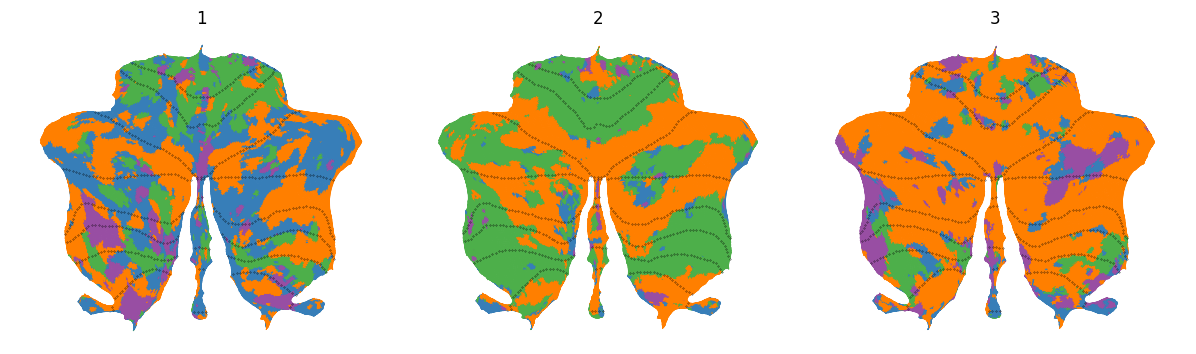

In [69]:
U_individual_volumes = get_volumes(best_comb_us[:3].cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,4),
                        bordersize = 0.5,
                        fig_size = (20,20))

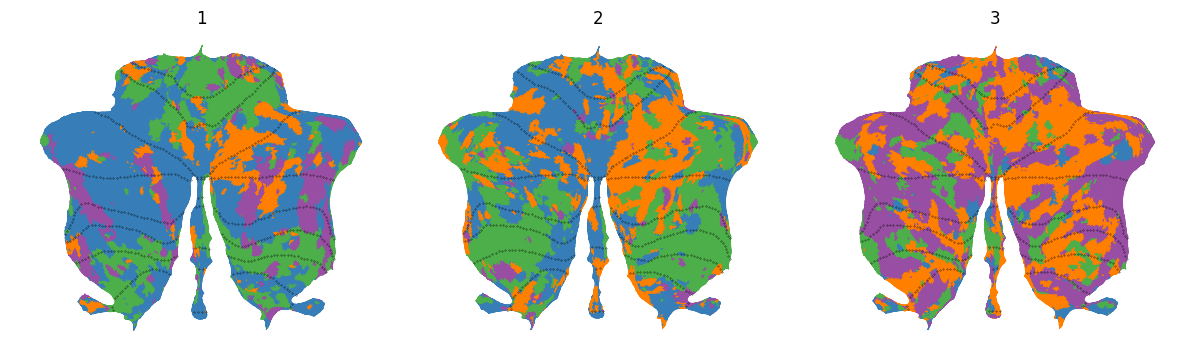

In [70]:
U_individual_volumes = get_volumes(worst_comb_us[:3].cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,4),
                        bordersize = 0.5,
                        fig_size = (20,20))